# Tail Assignment — Cash-Air — Benchmark multi-instances

**Problème** : Affecter une flotte d'avions à un ensemble de vols en minimisant le coût total d'affectation, sous contraintes opérationnelles.

**Structure du notebook** :
1. Imports & structures de données
2. Parsing du fichier `.dat`
3. Construction du graphe de compatibilité
4. Modèle CP-SAT (OR-Tools)
5. **Boucle sur 10 instances** — collecte solve time, coût, statut
6. **Statistiques agrégées** — mean & std deviation
7. Visualisations (Gantt sur la dernière instance)

**Instances** : `DataCplex_density=0.9_p=10_h=7_test_i.dat` pour i ∈ {0, …, 9}

## 1. Imports & structures de données

In [1]:
import re
from dataclasses import dataclass
from typing import List, Dict, Tuple, Set
from collections import defaultdict

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("Imports OK")

Imports OK


In [2]:
@dataclass(frozen=True)
class Flight:
    fid: int
    origin: str
    dest: str
    dep: float   # minutes cumulées
    arr: float   # minutes cumulées

print("Dataclass Flight définie")

Dataclass Flight définie


## 2. Parsing du fichier `.dat`

In [3]:
def parse_flights(text: str) -> List[Flight]:
    """Parse les vols depuis le bloc Flight = { ... }."""
    pat = re.compile(
        r"<\s*(\d+)\s*,\s*([A-Z]{2,4})\s*,\s*([A-Z]{2,4})\s*,\s*([0-9.]+)\s*,\s*([0-9.]+)\s*>"
    )
    flights = []
    for m in pat.finditer(text):
        fid = int(m.group(1))
        o   = m.group(2)
        d   = m.group(3)
        dep = float(m.group(4))
        arr = float(m.group(5))
        flights.append(Flight(fid, o, d, dep, arr))
    flights.sort(key=lambda f: f.fid)
    return flights


def parse_aircraft_bases(text: str) -> Dict[int, str]:
    """Parse les bases initiales des avions depuis Aircraft = [ ... ]."""
    pat = re.compile(r"Aircraft\s*=\s*\[(.*?)\];", re.DOTALL)
    m = pat.search(text)
    if not m:
        return {}
    block = m.group(1)
    pair_pat = re.compile(r"<\s*(\d+)\s*,\s*([A-Z]{2,4})\s*>")
    bases = {int(mm.group(1)): mm.group(2) for mm in pair_pat.finditer(block)}
    return bases


def parse_cost_matrix(text: str) -> np.ndarray:
    """Parse la matrice de coût Cost = [ [...], [...], ... ]."""
    pat = re.compile(r"Cost\s*=\s*\[(.*?\])\s*;\s*", re.DOTALL)
    m = pat.search(text)
    if not m:
        return np.array([])
    block = m.group(1)
    row_pat = re.compile(r"\[(.*?)\]")
    rows = []
    for rm in row_pat.finditer(block):
        row_str = rm.group(1).strip()
        if not row_str:
            continue
        vals = [float(x.strip()) for x in row_str.split(",") if x.strip()]
        rows.append(vals)
    return np.array(rows, dtype=float)

print("Parsers définis")

Parsers définis


In [4]:
# ─── Répertoire contenant les 10 fichiers de données ──────────────────────
DATA_DIR = r"C:\Users\lechh\Tail_assignment\Data\d=0.9"
DATASET_TEMPLATE = "DataCplex_density=0.9_p=10_h=7_test_{i}.dat"
N_INSTANCES = 10
# ──────────────────────────────────────────────────────────────────────────

import os

# Vérifie que les fichiers existent
for i in range(N_INSTANCES):
    path = os.path.join(DATA_DIR, DATASET_TEMPLATE.format(i=i))
    status = "✅" if os.path.exists(path) else "❌ MANQUANT"
    print(f"  [{i}] {os.path.basename(path)}  {status}")

print(f"\nRépertoire : {DATA_DIR}")


  [0] DataCplex_density=0.9_p=10_h=7_test_0.dat  ✅
  [1] DataCplex_density=0.9_p=10_h=7_test_1.dat  ✅
  [2] DataCplex_density=0.9_p=10_h=7_test_2.dat  ✅
  [3] DataCplex_density=0.9_p=10_h=7_test_3.dat  ✅
  [4] DataCplex_density=0.9_p=10_h=7_test_4.dat  ✅
  [5] DataCplex_density=0.9_p=10_h=7_test_5.dat  ✅
  [6] DataCplex_density=0.9_p=10_h=7_test_6.dat  ✅
  [7] DataCplex_density=0.9_p=10_h=7_test_7.dat  ✅
  [8] DataCplex_density=0.9_p=10_h=7_test_8.dat  ✅
  [9] DataCplex_density=0.9_p=10_h=7_test_9.dat  ✅

Répertoire : C:\Users\lechh\Tail_assignment\Data\d=0.9


## 3. Construction du graphe de compatibilité

Un arc (i → j) existe si :
- `dest(i) == origin(j)`  (C3 : no ferry)
- `arr(i) + τ ≤ dep(j)`  (C1 : turn time)

In [5]:
TAU = 0   # ← modifier ici pour l'analyse de sensibilité (0, 30, 45, 60, 90)
print(f"Turn time τ = {TAU} min")


Turn time τ = 0 min


In [10]:
def build_compatibility_edges(flights: List[Flight], tau: float) -> Set[Tuple[int, int]]:
    """Construit les arcs de compatibilité entre vols."""
    by_origin: Dict[str, List[Flight]] = {}
    for f in flights:
        by_origin.setdefault(f.origin, []).append(f)
    for k in by_origin:
        by_origin[k].sort(key=lambda x: x.dep)

    E = set()
    for fi in flights:
        candidates = by_origin.get(fi.dest, [])
        earliest = fi.arr + tau
        for fj in candidates:
            if fj.dep >= earliest:
                E.add((fi.fid, fj.fid))
    return E




In [12]:
def subgraph_by_time(flights, E, tmin, tmax):
    """Sous-graphe filtré par fenêtre temporelle (pour visualisation)."""
    ids = {f.fid for f in flights if tmin <= f.dep <= tmax}
    G = nx.DiGraph()
    for fid in ids:
        G.add_node(fid)
    for (i, j) in E:
        if i in ids and j in ids:
            G.add_edge(i, j)
    return G


In [8]:
#─── Visualisation du graphe de compatibilité (sur la première instance) ─
# Cette cellule est exécutée après la boucle benchmarks, sur la dernière instance.
# Décommenter si besoin.

G_small = subgraph_by_time(flights, E, 0, 1500)
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_small, seed=0)
nx.draw_networkx_nodes(G_small, pos, node_size=300, node_color="steelblue", alpha=0.8)
nx.draw_networkx_edges(G_small, pos, arrows=True, alpha=0.4, edge_color="gray")
nx.draw_networkx_labels(G_small, pos, font_size=8, font_color="white")
plt.title(f"Graphe de compatibilité (τ={TAU} min) — sous-graphe dep ∈ [0, 1500]")
plt.axis("off")
plt.tight_layout()
plt.show()
print("Cellule de visualisation graphe commentée (exécuter après la boucle si besoin).")


NameError: name 'subgraph_by_time' is not defined

## 4. Modèle CP-SAT (OR-Tools)

**Variables** :
- $x_i^a \in \{0,1\}$ : vol $i$ affecté à l'avion $a$
- $z_i^a \in \{0,1\}$ : vol $i$ est le premier vol de l'avion $a$
- $y_{ij}^a \in \{0,1\}$ : enchaînement $(i \to j)$ pour l'avion $a$

**Objectif** : $\min \sum_{i,a} c_{i,a} \cdot x_i^a$

**Contraintes** :
- (C0) Chaque vol est affecté à exactement un avion
- (C1) Lien affectation / entrée dans la chaîne : $x_i^a = z_i^a + \sum_{j:(j,i)\in E} y_{ji}^a$
- (C2) Pas de branchement : $\sum_{j:(i,j)\in E} y_{ij}^a \leq x_i^a$
- (C3) Un départ par avion : $\sum_i z_i^a = 1$
- (C4) Faisabilité du départ : $z_i^a = 0$ si $\text{origin}(i) \neq \text{base}(a)$

In [6]:
try:
    from ortools.sat.python import cp_model
    ORTOOLS_OK = True
    print("OR-Tools disponible ✓")
except Exception as e:
    ORTOOLS_OK = False
    print("OR-Tools non disponible :", e)

OR-Tools disponible ✓


In [14]:
def solve_tail_assignment(flights, aircraft_bases, cost, E, time_limit_s=60.0):
    """Résout le problème de Tail Assignment avec CP-SAT."""
    if not ORTOOLS_OK:
        raise RuntimeError("OR-Tools requis.")

    flight_ids   = [f.fid for f in flights]
    aircraft_ids = sorted(aircraft_bases.keys())
    fid_to_idx   = {fid: k for k, fid in enumerate(flight_ids)}
    a_to_col     = {a: j for j, a in enumerate(aircraft_ids)}
    fid_to_f     = {f.fid: f for f in flights}

    # Pré-calcul des démarrages faisables (C4)
    feasible_start = {
        (fid, a): (fid_to_f[fid].origin == aircraft_bases[a])
        for fid in flight_ids for a in aircraft_ids
    }

    # ─── Pré-calcul des voisins (accélère l'extraction) ────────────────────
    outgoing_map = defaultdict(list)   # fid → [fid_suivant, ...]
    incoming_map = defaultdict(list)   # fid → [fid_précédent, ...]
    for (i, j) in E:
        outgoing_map[i].append(j)
        incoming_map[j].append(i)

    model = cp_model.CpModel()

    x, z, y = {}, {}, {}
    for fid in flight_ids:
        for a in aircraft_ids:
            x[(fid, a)] = model.NewBoolVar(f"x_{fid}_{a}")
            z[(fid, a)] = model.NewBoolVar(f"z_{fid}_{a}")
            if not feasible_start[(fid, a)]:
                model.Add(z[(fid, a)] == 0)

    for (i, j) in E:
        for a in aircraft_ids:
            y[(i, j, a)] = model.NewBoolVar(f"y_{i}_{j}_{a}")

    # (C0) Chaque vol exactement une fois
    for fid in flight_ids:
        model.Add(sum(x[(fid, a)] for a in aircraft_ids) == 1)

    # Listes d'arcs entrants/sortants par (fid, avion)
    incoming = {(fid, a): [] for fid in flight_ids for a in aircraft_ids}
    outgoing = {(fid, a): [] for fid in flight_ids for a in aircraft_ids}
    for (i, j) in E:
        for a in aircraft_ids:
            incoming[(j, a)].append(y[(i, j, a)])
            outgoing[(i, a)].append(y[(i, j, a)])

    # (C1) x = z + entrants
    for fid in flight_ids:
        for a in aircraft_ids:
            model.Add(x[(fid, a)] == z[(fid, a)] + sum(incoming[(fid, a)]))

    # (C2) Pas de branchement
    for fid in flight_ids:
        for a in aircraft_ids:
            model.Add(sum(outgoing[(fid, a)]) <= x[(fid, a)])

    # (C3) Un départ par avion
    for a in aircraft_ids:
        model.Add(sum(z[(fid, a)] for fid in flight_ids) == 1)

    # Objectif
    obj_terms = []
    for fid in flight_ids:
        i = fid_to_idx[fid]
        for a in aircraft_ids:
            j = a_to_col[a]
            obj_terms.append(int(round(cost[i, j])) * x[(fid, a)])
    model.Minimize(sum(obj_terms))

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit_s
    solver.parameters.num_search_workers  = 8

    status = solver.Solve(model)
    return status, solver, (x, z, y), (flight_ids, aircraft_ids), outgoing_map




In [15]:
# ─── Boucle benchmark sur les 10 instances ────────────────────────────────
import time
from ortools.sat.python import cp_model as _cp

benchmark_results = []   # liste de dicts — une entrée par instance

# Variables conservées pour la dernière instance (utiles pour les visuels)
flights = bases = cost = E = None
status = solver = vars_pack = idx_pack = outgoing_map = None
rotations = df_rot = None

for i in range(N_INSTANCES):
    data_path = os.path.join(DATA_DIR, DATASET_TEMPLATE.format(i=i))
    print(f"\n{'='*60}")
    print(f"Instance {i:2d} : {os.path.basename(data_path)}")
    print(f"{'='*60}")

    # ── Parsing ────────────────────────────────────────────────────────────
    with open(data_path, "r") as fh:
        file_text = fh.read()

    _flights = parse_flights(file_text)
    _bases   = parse_aircraft_bases(file_text)
    _cost    = parse_cost_matrix(file_text)
    print(f"  Vols : {len(_flights)} | Avions : {len(_bases)} | Coût shape : {_cost.shape}")

    # ── Graphe de compatibilité ────────────────────────────────────────────
    _E = build_compatibility_edges(_flights, TAU)
    print(f"  Arcs de compatibilité : {len(_E)}")

    # ── Solve ─────────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    _status, _solver, _vars_pack, _idx_pack, _outgoing_map = solve_tail_assignment(
        _flights, _bases, _cost, _E, time_limit_s=120.0
    )
    solve_time = time.perf_counter() - t0

    # ── Interprétation du statut ───────────────────────────────────────────
    feasible = _status in [_cp.OPTIMAL, _cp.FEASIBLE]
    if _status == _cp.OPTIMAL:
        status_str = "OPTIMAL"
    elif _status == _cp.FEASIBLE:
        status_str = "FEASIBLE"
    elif _status == _cp.INFEASIBLE:
        status_str = "INFEASIBLE"
    else:
        status_str = "UNKNOWN/TIMEOUT"

    obj_value = _solver.ObjectiveValue() if feasible else None
    best_bound = _solver.BestObjectiveBound() if feasible else None
    gap = abs(obj_value - best_bound) / (abs(obj_value) + 1e-9) * 100 if feasible and obj_value else None

    print(f"  Statut     : {status_str}")
    print(f"  Solve time : {solve_time:.3f} s")
    if feasible:
        print(f"  Coût       : {obj_value:,.1f}")
        print(f"  Best bound : {best_bound:,.1f}")
        print(f"  Gap        : {gap:.4f} %")

    benchmark_results.append({
        "instance"    : i,
        "fichier"     : os.path.basename(data_path),
        "nb_vols"     : len(_flights),
        "nb_avions"   : len(_bases),
        "nb_arcs"     : len(_E),
        "statut"      : status_str,
        "solve_time_s": round(solve_time, 4),
        "cout"        : obj_value,
        "best_bound"  : best_bound,
        "gap_pct"     : round(gap, 6) if gap is not None else None,
    })

    # Conserver la dernière instance pour les visualisations
    flights, bases, cost, E = _flights, _bases, _cost, _E
    status, solver, vars_pack, idx_pack, outgoing_map = (
        _status, _solver, _vars_pack, _idx_pack, _outgoing_map
    )

print("\n✅ Boucle terminée.")



Instance  0 : DataCplex_density=0.9_p=10_h=7_test_0.dat
  Vols : 167 | Avions : 10 | Coût shape : (167, 10)
  Arcs de compatibilité : 1389
  Statut     : OPTIMAL
  Solve time : 12.354 s
  Coût       : 1,349,297.0
  Best bound : 1,349,297.0
  Gap        : 0.0000 %

Instance  1 : DataCplex_density=0.9_p=10_h=7_test_1.dat
  Vols : 185 | Avions : 10 | Coût shape : (185, 10)
  Arcs de compatibilité : 1738
  Statut     : OPTIMAL
  Solve time : 29.530 s
  Coût       : 1,500,707.0
  Best bound : 1,500,707.0
  Gap        : 0.0000 %

Instance  2 : DataCplex_density=0.9_p=10_h=7_test_2.dat
  Vols : 205 | Avions : 10 | Coût shape : (205, 10)
  Arcs de compatibilité : 2189
  Statut     : OPTIMAL
  Solve time : 47.745 s
  Coût       : 1,665,214.0
  Best bound : 1,665,214.0
  Gap        : 0.0000 %

Instance  3 : DataCplex_density=0.9_p=10_h=7_test_3.dat
  Vols : 182 | Avions : 10 | Coût shape : (182, 10)
  Arcs de compatibilité : 1700
  Statut     : OPTIMAL
  Solve time : 18.006 s
  Coût       : 1,4

## 5. Résultats agrégés — Mean & Standard Deviation


Résultats par instance :


' instance                                   fichier  nb_vols  nb_avions  nb_arcs   statut  solve_time_s      cout  best_bound  gap_pct\n        0 DataCplex_density=0.9_p=10_h=7_test_0.dat      167         10     1389  OPTIMAL       12.3539 1349297.0   1349297.0 0.000000\n        1 DataCplex_density=0.9_p=10_h=7_test_1.dat      185         10     1738  OPTIMAL       29.5305 1500707.0   1500707.0 0.000000\n        2 DataCplex_density=0.9_p=10_h=7_test_2.dat      205         10     2189  OPTIMAL       47.7450 1665214.0   1665214.0 0.000000\n        3 DataCplex_density=0.9_p=10_h=7_test_3.dat      182         10     1700  OPTIMAL       18.0055 1481283.0   1481283.0 0.000000\n        4 DataCplex_density=0.9_p=10_h=7_test_4.dat      166         10     1444  OPTIMAL       12.4528 1344427.0   1344427.0 0.000000\n        5 DataCplex_density=0.9_p=10_h=7_test_5.dat      184         10     1697  OPTIMAL       22.9820 1496786.0   1496786.0 0.000000\n        6 DataCplex_density=0.9_p=10_h=7_test_6


STATISTIQUES AGRÉGÉES (instances résolues : 10/10)
Métrique                        Mean         Std Dev
----------------------------------------------------
Solve time (s)               37.6177         37.0386
Coût optimal            1530906.6000     183684.4550
Best bound              1530885.8000     183634.9279
Gap (%)                       0.0011          0.0034


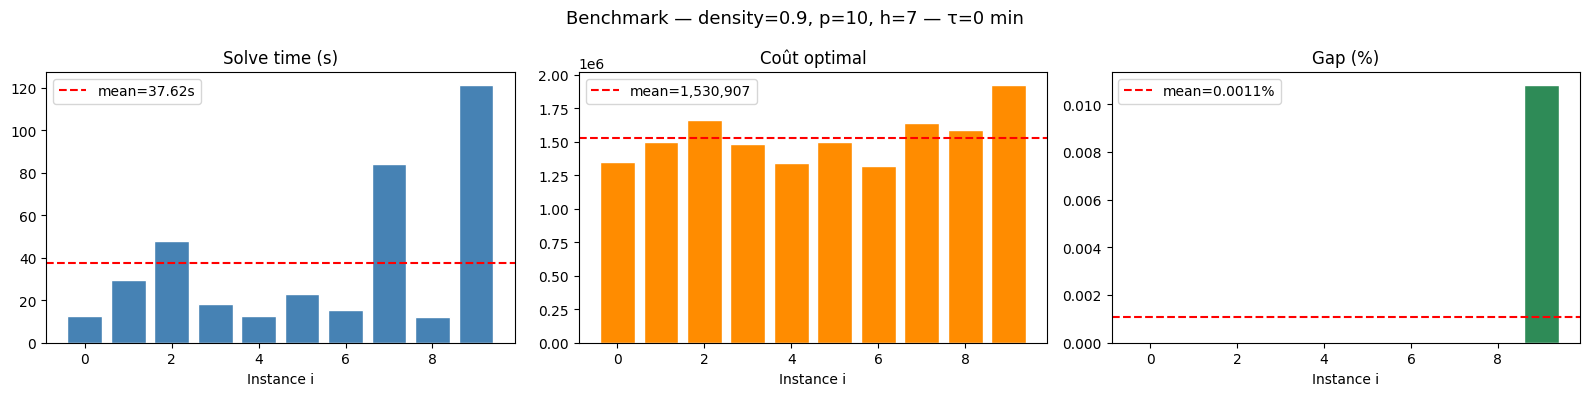

Graphique sauvegardé : benchmark_stats.png


In [16]:
# ─── Tableau récapitulatif des 10 instances ───────────────────────────────
df_bench = pd.DataFrame(benchmark_results)
print("Résultats par instance :")
display(df_bench.to_string(index=False))

# ── Statistiques sur les instances résolues ───────────────────────────────
df_solved = df_bench[df_bench["statut"].isin(["OPTIMAL", "FEASIBLE"])].copy()

metrics = ["solve_time_s", "cout", "best_bound", "gap_pct"]
agg = df_solved[metrics].agg(["mean", "std"])

print("\n" + "="*60)
print("STATISTIQUES AGRÉGÉES (instances résolues : "
      f"{len(df_solved)}/{len(df_bench)})")
print("="*60)
print(f"{'Métrique':<20} {'Mean':>15} {'Std Dev':>15}")
print("-"*52)
labels = {
    "solve_time_s" : "Solve time (s)",
    "cout"         : "Coût optimal",
    "best_bound"   : "Best bound",
    "gap_pct"      : "Gap (%)",
}
for m in metrics:
    mean_val = agg.loc["mean", m]
    std_val  = agg.loc["std",  m]
    if mean_val is not None and not pd.isna(mean_val):
        print(f"{labels[m]:<20} {mean_val:>15.4f} {std_val:>15.4f}")
    else:
        print(f"{labels[m]:<20} {'N/A':>15} {'N/A':>15}")
print("="*60)

# ── Graphique comparatif ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

x = df_bench["instance"]

axes[0].bar(x, df_bench["solve_time_s"], color="steelblue", edgecolor="white")
axes[0].axhline(agg.loc["mean", "solve_time_s"], color="red",
                linestyle="--", label=f"mean={agg.loc['mean','solve_time_s']:.2f}s")
axes[0].set_title("Solve time (s)")
axes[0].set_xlabel("Instance i")
axes[0].legend()

axes[1].bar(x, df_bench["cout"].fillna(0), color="darkorange", edgecolor="white")
axes[1].axhline(agg.loc["mean", "cout"], color="red",
                linestyle="--", label=f"mean={agg.loc['mean','cout']:,.0f}")
axes[1].set_title("Coût optimal")
axes[1].set_xlabel("Instance i")
axes[1].legend()

axes[2].bar(x, df_bench["gap_pct"].fillna(0), color="seagreen", edgecolor="white")
axes[2].axhline(agg.loc["mean", "gap_pct"], color="red",
                linestyle="--", label=f"mean={agg.loc['mean','gap_pct']:.4f}%")
axes[2].set_title("Gap (%)")
axes[2].set_xlabel("Instance i")
axes[2].legend()

plt.suptitle(f"Benchmark — density=0.9, p=10, h=7 — τ={TAU} min", fontsize=13)
plt.tight_layout()
plt.savefig("benchmark_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : benchmark_stats.png")


## 6. Extraction & visualisation — dernière instance

Les cellules suivantes opèrent sur la **dernière instance** (i=9) pour illustrer la solution.


## 6b. Extraction & validation de la solution


In [ ]:
def extract_solution(flights, E, solver, vars_pack, idx_pack, outgoing_map):
    """
    Extrait les rotations par avion depuis la solution CP-SAT.
    Utilise outgoing_map pour éviter l'itération sur tous les arcs (O(n) vs O(|E|)).
    """
    x, z, y = vars_pack
    flight_ids, aircraft_ids = idx_pack
    fid_to_f = {f.fid: f for f in flights}

    rotations = {}
    for a in aircraft_ids:
        # Trouver le vol de départ
        start = next(
            (fid for fid in flight_ids if solver.Value(z[(fid, a)]) == 1),
            None
        )
        if start is None:
            rotations[a] = []
            continue

        chain   = [start]
        current = start
        visited = {start}

        while True:
            # Chercher le suivant parmi les voisins sortants de 'current'
            nxt = next(
                (j for j in outgoing_map[current]
                 if (current, j, a) in y and solver.Value(y[(current, j, a)]) == 1),
                None
            )
            if nxt is None or nxt in visited:
                break
            chain.append(nxt)
            visited.add(nxt)
            current = nxt

        rotations[a] = chain

    # Construire le DataFrame
    rows = []
    for a, chain in rotations.items():
        for k, fid in enumerate(chain):
            f = fid_to_f[fid]
            rows.append({
                "aircraft": a,
                "seq"     : k,
                "fid"     : fid,
                "origin"  : f.origin,
                "dest"    : f.dest,
                "dep"     : f.dep,
                "arr"     : f.arr,
            })

    df_rot = pd.DataFrame(rows).sort_values(["aircraft", "seq"]).reset_index(drop=True)
    return rotations, df_rot


rotations, df_rot = extract_solution(flights, E, solver, vars_pack, idx_pack, outgoing_map)
print(f"Rotations extraites pour {len(rotations)} avions")
df_rot.head(20)

In [ ]:
# ─── Validation complète de la solution ────────────────────────────────────

all_fids         = {f.fid for f in flights}
assigned_fids    = set(df_rot["fid"].tolist())
missing_fids     = all_fids - assigned_fids
duplicate_fids   = df_rot[df_rot.duplicated("fid")]["fid"].tolist()

print("=" * 50)
print("VALIDATION DE LA SOLUTION")
print("=" * 50)

# 1) Couverture
print(f"\n[1] Couverture des vols")
print(f"    Vols attendus  : {len(all_fids)}")
print(f"    Vols assignés  : {len(assigned_fids)}")
if missing_fids:
    print(f"    ❌ Vols manquants : {sorted(missing_fids)}")
else:
    print(f"    ✅ Tous les vols sont couverts")

# 2) Unicité
print(f"\n[2] Unicité des affectations")
if duplicate_fids:
    print(f"    ❌ Vols assignés plusieurs fois : {duplicate_fids}")
else:
    print(f"    ✅ Chaque vol est assigné exactement une fois")

# 3) Turn time
print(f"\n[3] Respect du turn time (τ = {TAU} min)")
violations_tt = []
for a, chain in rotations.items():
    fid_to_f = {f.fid: f for f in flights}
    for k in range(len(chain) - 1):
        fi = fid_to_f[chain[k]]
        fj = fid_to_f[chain[k + 1]]
        if fj.dep < fi.arr + TAU:
            violations_tt.append((a, fi.fid, fj.fid, fi.arr, fj.dep))
if violations_tt:
    print(f"    ❌ {len(violations_tt)} violation(s) de turn time")
    for v in violations_tt[:5]:
        print(f"       avion={v[0]}, vol {v[1]}→{v[2]}, arr={v[3]}, dep={v[4]}")
else:
    print(f"    ✅ Turn time respecté pour toutes les rotations")

# 4) Contrainte de base (C2)
print(f"\n[4] Contrainte de base initiale")
violations_base = []
for a, chain in rotations.items():
    if chain:
        first_flight = {f.fid: f for f in flights}[chain[0]]
        if first_flight.origin != bases[a]:
            violations_base.append((a, chain[0], first_flight.origin, bases[a]))
if violations_base:
    print(f"    ❌ Violations de base : {violations_base}")
else:
    print(f"    ✅ Tous les avions démarrent depuis leur base")

# 5) No-ferry (C3)
print(f"\n[5] Contrainte no-ferry")
violations_ferry = []
for a, chain in rotations.items():
    fid_to_f = {f.fid: f for f in flights}
    for k in range(len(chain) - 1):
        fi = fid_to_f[chain[k]]
        fj = fid_to_f[chain[k + 1]]
        if fi.dest != fj.origin:
            violations_ferry.append((a, fi.fid, fj.fid, fi.dest, fj.origin))
if violations_ferry:
    print(f"    ❌ {len(violations_ferry)} violation(s) no-ferry")
else:
    print(f"    ✅ Contrainte no-ferry respectée")

print("\n" + "=" * 50)
print(f"Coût total optimal : {solver.ObjectiveValue():,.1f}")
print("=" * 50)

In [ ]:
# ─── Résumé par avion ───────────────────────────────────────────────────────
summary_rows = []
fid_to_f = {f.fid: f for f in flights}
for a, chain in rotations.items():
    if not chain:
        summary_rows.append({"aircraft": a, "nb_vols": 0,
                              "premier_aeroport": bases[a],
                              "dernier_aeroport": bases[a],
                              "dep_premier": None, "arr_dernier": None})
        continue
    first = fid_to_f[chain[0]]
    last  = fid_to_f[chain[-1]]
    summary_rows.append({
        "aircraft"        : a,
        "nb_vols"         : len(chain),
        "premier_aeroport": first.origin,
        "dernier_aeroport": last.dest,
        "dep_premier (min)": first.dep,
        "arr_dernier (min)": last.arr,
    })

df_summary = pd.DataFrame(summary_rows).set_index("aircraft")
print("Résumé des rotations par avion :")
df_summary

## 6. Visualisations

In [ ]:
# ─── Gantt chart par avion ──────────────────────────────────────────────────

aircraft_ids_sorted = sorted(rotations.keys())
n_aircraft = len(aircraft_ids_sorted)

# Palette de couleurs (une par avion)
cmap   = plt.get_cmap("tab10", n_aircraft)
colors = {a: cmap(i) for i, a in enumerate(aircraft_ids_sorted)}

fig, ax = plt.subplots(figsize=(18, 6))

for row_idx, a in enumerate(aircraft_ids_sorted):
    chain = rotations[a]
    for fid in chain:
        f = fid_to_f[fid]
        ax.barh(
            y      = row_idx,
            width  = f.arr - f.dep,
            left   = f.dep,
            height = 0.6,
            color  = colors[a],
            edgecolor = "white",
            linewidth = 0.5,
        )
        # Label du vol (affiché si barre assez large)
        if f.arr - f.dep > 30:
            ax.text(
                (f.dep + f.arr) / 2, row_idx,
                str(fid),
                ha="center", va="center",
                fontsize=6, color="white", fontweight="bold"
            )

ax.set_yticks(range(n_aircraft))
ax.set_yticklabels([f"Aircraft {a}  (base: {bases[a]})" for a in aircraft_ids_sorted])
ax.set_xlabel("Temps (minutes cumulées)")
ax.set_title(f"Gantt — Rotations par avion  |  τ={TAU} min  |  Coût optimal = {solver.ObjectiveValue():,.0f}")
ax.grid(axis="x", linestyle="--", alpha=0.4)

# Légende
patches = [mpatches.Patch(color=colors[a], label=f"Aircraft {a}") for a in aircraft_ids_sorted]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("gantt_rotations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gantt sauvegardé : gantt_rotations.png")

In [ ]:
# ─── Gantt détaillé : une figure par avion ──────────────────────────────────

fig, axes = plt.subplots(n_aircraft, 1, figsize=(18, 2.5 * n_aircraft), sharex=True)
if n_aircraft == 1:
    axes = [axes]

for ax, a in zip(axes, aircraft_ids_sorted):
    chain = rotations[a]
    for k, fid in enumerate(chain):
        f = fid_to_f[fid]
        ax.barh(
            y=0, width=f.arr - f.dep, left=f.dep,
            height=0.5, color=colors[a], edgecolor="white", linewidth=0.8
        )
        ax.text(
            (f.dep + f.arr) / 2, 0,
            f"{fid}\n{f.origin}→{f.dest}",
            ha="center", va="center",
            fontsize=6.5, color="white", fontweight="bold"
        )
    ax.set_yticks([0])
    ax.set_yticklabels([f"A{a} ({bases[a]})"])
    ax.set_xlim(left=0)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_ylabel(f"Aircraft {a}", rotation=0, labelpad=60, va="center")

axes[-1].set_xlabel("Temps (minutes cumulées)")
plt.suptitle(f"Rotations détaillées par avion  |  τ={TAU} min", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("gantt_detail.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gantt détaillé sauvegardé : gantt_detail.png")

## 7. Analyse de sensibilité au turn time (optionnel)

Décommenter et exécuter pour comparer les résultats avec différentes valeurs de τ.

In [ ]:
# ─── Décommenter pour lancer l'analyse de sensibilité ───────────────────────

# taus = [0, 30, 45, 60, 90]
# results = []
# 
# for tau in taus:
#     E_tau = build_compatibility_edges(flights, tau)
#     st, sol, vp, ip, om = solve_tail_assignment(flights, bases, cost, E_tau, time_limit_s=120.0)
#     from ortools.sat.python import cp_model as cp
#     feasible = st in [cp.CpSolverStatus.OPTIMAL, cp.CpSolverStatus.FEASIBLE]
#     results.append({
#         "tau (min)"  : tau,
#         "arcs"       : len(E_tau),
#         "statut"     : "OPTIMAL" if st == cp.CpSolverStatus.OPTIMAL else ("FEASIBLE" if feasible else "INFEASIBLE"),
#         "coût"       : sol.ObjectiveValue() if feasible else None,
#     })
#     print(f"τ={tau:3d} | arcs={len(E_tau):5d} | statut={results[-1]['statut']} | coût={results[-1]['coût']}")
# 
# pd.DataFrame(results).set_index("tau (min)")

print("Cellule de sensibilité commentée. Décommenter pour exécuter.")